# Fixed-dt Binary Diagnostics (Analytic-Relative)

Self-contained notebook for MG vs FMM diagnostics against an analytic circular binary reference (L5/L6/L7).


In [10]:
%matplotlib inline

from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from IPython.display import display, Image

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "serif"
plt.rcParams["figure.dpi"] = 150
plt.rcParams.update({
    "font.size": 16,
    "legend.fontsize": 20,
})

G = 1.0
SOLVERS = ("mg", "fmm")
COLORS = {"mg": "#1f77b4", "fmm": "#d62728"}
LINESTYLES = {"l5": "-", "l6": "--", "l7": ":"}


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "utils/py/miniramses.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root from current path.")


repo_root = find_repo_root(Path.cwd())
binary_root = repo_root / "binary_test"
output_dir = binary_root / "analysis_fixed_dt"
levels = ("l5", "l6", "l7")

if str(repo_root / "utils/py") not in sys.path:
    sys.path.append(str(repo_root / "utils/py"))
import miniramses as ram

print(f"Repo root:   {repo_root}")
print(f"Binary root: {binary_root}")
print(f"Output dir:  {output_dir}")


Repo root:   /Users/jylee/Ramses-FMM
Binary root: /Users/jylee/Ramses-FMM/binary_test
Output dir:  /Users/jylee/Ramses-FMM/binary_test/analysis_fixed_dt


In [11]:
def apply_plot_style() -> None:
    return

def style_axis(ax, integer_x_ticks: bool = False) -> None:
    ax.grid(True, alpha=0.35)
    if integer_x_ticks:
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))


def list_outputs(run_dir: Path) -> list[int]:
    outputs = [int(p.name.split("_")[-1]) for p in run_dir.glob("output_*") if p.is_dir()]
    outputs.sort()
    if not outputs:
        raise FileNotFoundError(f"No output_* directories found in {run_dir}")
    return outputs


def ordered_particle_state(part) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    order = np.argsort(part.birth_id.astype(np.int64))
    pos = np.asarray(part.pos[:, order], dtype=np.float64)
    vel = np.asarray(part.vel[:, order], dtype=np.float64)
    mass = np.asarray(part.mass[order], dtype=np.float64)
    return pos, vel, mass


def load_solver_history(run_dir: Path) -> pd.DataFrame:
    rows: list[dict[str, float]] = []
    for nout in list_outputs(run_dir):
        info = ram.rd_info(nout, path=str(run_dir))
        part = ram.rd_part(nout, path=str(run_dir), silent=True)
        if int(part.npart) != 2:
            raise ValueError(f"Expected exactly 2 particles in {run_dir}/output_{nout:05d}, found {part.npart}")

        pos, vel, mass = ordered_particle_state(part)
        rel_pos = pos[:, 1] - pos[:, 0]
        rel_vel = vel[:, 1] - vel[:, 0]
        sep = float(np.linalg.norm(rel_pos))

        com = np.sum(pos * mass[None, :], axis=1) / np.sum(mass)
        kinetic = float(0.5 * np.sum(mass * np.sum(vel**2, axis=0)))
        potential = float(-G * mass[0] * mass[1] / sep)
        angmom = np.sum(np.cross(pos.T, (mass[None, :] * vel).T), axis=0)

        rows.append(
            {
                "time": float(info.time),
                "m1": float(mass[0]),
                "m2": float(mass[1]),
                "x1": float(pos[0, 0]),
                "y1": float(pos[1, 0]),
                "x2": float(pos[0, 1]),
                "y2": float(pos[1, 1]),
                "vx1": float(vel[0, 0]),
                "vy1": float(vel[1, 0]),
                "vx2": float(vel[0, 1]),
                "vy2": float(vel[1, 1]),
                "sep": sep,
                "phase": float(np.arctan2(rel_pos[1], rel_pos[0])),
                "rel_vx": float(rel_vel[0]),
                "rel_vy": float(rel_vel[1]),
                "com_x": float(com[0]),
                "com_y": float(com[1]),
                "com_z": float(com[2]),
                "kinetic": kinetic,
                "potential": potential,
                "energy": kinetic + potential,
                "lx": float(angmom[0]),
                "ly": float(angmom[1]),
                "lz": float(angmom[2]),
            }
        )

    df = pd.DataFrame(rows).sort_values("time").reset_index(drop=True)
    df["phase_unwrapped"] = np.unwrap(df["phase"].to_numpy())
    df["orbits_completed"] = df["phase_unwrapped"] / (2.0 * np.pi)
    df["lmag"] = np.sqrt(df["lx"] ** 2 + df["ly"] ** 2 + df["lz"] ** 2)

    sep0 = float(df["sep"].iloc[0])
    e0 = float(df["energy"].iloc[0])
    l0 = float(df["lmag"].iloc[0])
    com0 = df.loc[0, ["com_x", "com_y", "com_z"]].to_numpy(dtype=float)
    m1 = float(df["m1"].iloc[0])
    m2 = float(df["m2"].iloc[0])
    mtot = float(m1 + m2)

    r0 = np.array([df["x2"].iloc[0] - df["x1"].iloc[0], df["y2"].iloc[0] - df["y1"].iloc[0]], dtype=float)
    v0 = np.array([df["vx2"].iloc[0] - df["vx1"].iloc[0], df["vy2"].iloc[0] - df["vy1"].iloc[0]], dtype=float)
    omega = float(np.sqrt(G * mtot / sep0**3))
    sign = float(np.sign(r0[0] * v0[1] - r0[1] * v0[0]))
    if sign == 0.0:
        sign = 1.0

    phi0 = float(np.arctan2(r0[1], r0[0]))
    phase_ref = phi0 + sign * omega * df["time"].to_numpy()
    phase_ref = np.unwrap(phase_ref)

    xrel_ref = sep0 * np.cos(phase_ref)
    yrel_ref = sep0 * np.sin(phase_ref)
    x1_ref = com0[0] - (m2 / mtot) * xrel_ref
    y1_ref = com0[1] - (m2 / mtot) * yrel_ref
    x2_ref = com0[0] + (m1 / mtot) * xrel_ref
    y2_ref = com0[1] + (m1 / mtot) * yrel_ref

    df["sep_rel_dev"] = (df["sep"] - sep0) / sep0
    df["energy_rel_drift"] = (df["energy"] - e0) / abs(e0)
    df["lmag_rel_drift"] = (df["lmag"] - l0) / abs(l0)
    df["phase_err"] = df["phase_unwrapped"] - phase_ref

    body1_err = np.sqrt((df["x1"].to_numpy() - x1_ref) ** 2 + (df["y1"].to_numpy() - y1_ref) ** 2)
    body2_err = np.sqrt((df["x2"].to_numpy() - x2_ref) ** 2 + (df["y2"].to_numpy() - y2_ref) ** 2)

    df["body_err"] = 0.5 * (body1_err + body2_err)
    df["com_r"] = np.sqrt(
        (df["com_x"] - com0[0]) ** 2 + (df["com_y"] - com0[1]) ** 2 + (df["com_z"] - com0[2]) ** 2
    )
    return df


def make_main_figure(
    histories: dict[tuple[str, str], pd.DataFrame],
    out_png: Path,
    levels: tuple[str, ...],
    level_labels: dict[str, str] | None = None,
) -> pd.DataFrame:
    apply_plot_style()
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

    if level_labels is None:
        level_labels = {level: level.upper() for level in levels}

    summary_rows: list[dict[str, float | str]] = []
    for (solver, level), df in histories.items():
        color = COLORS[solver]
        ls = LINESTYLES[level]
        label = f"{solver.upper()} {level_labels.get(level, level.upper())}"
        t = df["time"].to_numpy()

        axes[0, 0].plot(t, df["energy_rel_drift"], color=color, linestyle=ls, linewidth=2.0, label=label)
        axes[0, 1].plot(t, df["lmag_rel_drift"], color=color, linestyle=ls, linewidth=2.0, label=label)
        axes[0, 2].plot(t, np.maximum(df["com_r"], 1e-16), color=color, linestyle=ls, linewidth=2.0, label=label)
        axes[1, 0].plot(t, df["sep_rel_dev"], color=color, linestyle=ls, linewidth=2.0, label=label)
        axes[1, 1].plot(t, df["phase_err"], color=color, linestyle=ls, linewidth=2.0, label=label)
        axes[1, 2].plot(t, df["body_err"], color=color, linestyle=ls, linewidth=2.0, label=label)

        summary_rows.append(
            {
                "solver": solver.upper(),
                "level": level_labels.get(level, level.upper()),
                "t_end": float(t[-1]),
                "max_abs_energy_rel_drift": float(np.max(np.abs(df["energy_rel_drift"]))),
                "max_abs_lmag_rel_drift": float(np.max(np.abs(df["lmag_rel_drift"]))),
                "max_com_drift": float(np.max(df["com_r"])),
                "max_abs_sep_rel_dev": float(np.max(np.abs(df["sep_rel_dev"]))),
                "max_abs_phase_err": float(np.max(np.abs(df["phase_err"]))),
                "final_phase_err": float(df["phase_err"].iloc[-1]),
                "max_body_err": float(np.max(df["body_err"])),
            }
        )

    axes[0, 0].set_title("Energy Drift")
    axes[0, 0].set_ylabel(r"$\Delta E/|E_0|$")
    axes[0, 1].set_title("Angular Momentum Drift")
    axes[0, 1].set_ylabel(r"$\Delta L/|L_0|$")
    axes[0, 2].set_title("Center-of-Mass Drift")
    axes[0, 2].set_ylabel(r"$|r_{COM} - r_{COM,0}|$")
    axes[0, 2].set_yscale("log")
    axes[1, 0].set_title("Interparticle Distance Deviation")
    axes[1, 0].set_ylabel(r"$(r-r_0)/r_0$")
    axes[1, 1].set_title("Phase Error vs Analytic")
    axes[1, 1].set_ylabel(r"$\Delta \phi$ [rad]")
    axes[1, 2].set_title("Mean Body Position Error vs Analytic")
    axes[1, 2].set_ylabel(r"$\frac{|x_1-x_{1,ana}|+|x_2-x_{2,ana}|}{2}$")

    for ax in axes.flat:
        ax.set_xlabel("Time")
        style_axis(ax)

    solver_handles = [Line2D([0], [0], color=COLORS[s], lw=2.5, linestyle="-", label=s.upper()) for s in SOLVERS]
    level_handles = [
        Line2D([0], [0], color="#333333", lw=2.5, linestyle=LINESTYLES[l], label=level_labels.get(l, l.upper()))
        for l in levels
    ]
    combined_handles = solver_handles + level_handles

    legend_ax = fig.add_axes([1.01, 0.14, 0.34, 0.72])
    legend_ax.axis("off")
    legend_ax.legend(
        handles=combined_handles,
        #title="Color = Solver | Linestyle = AMR Level",
        loc="upper left",
        bbox_to_anchor=(0.0, 1.0),
        ncol=1,
        frameon=True,
        borderaxespad=0.0,
    )

    fig.savefig(out_png, dpi=180, bbox_inches="tight")
    plt.close(fig)
    return pd.DataFrame(summary_rows)


def make_delta_figure(
    histories: dict[tuple[str, str], pd.DataFrame],
    out_png: Path,
    levels: tuple[str, ...],
    level_labels: dict[str, str] | None = None,
) -> pd.DataFrame:
    apply_plot_style()
    fig, axes = plt.subplots(2, 3, figsize=(11.5, 6.7), constrained_layout=True)

    if level_labels is None:
        level_labels = {level: level.upper() for level in levels}

    palette = ["#2ca02c", "#ff7f0e", "#9467bd", "#8c564b", "#17becf", "#bcbd22"]
    level_colors = {level: palette[i % len(palette)] for i, level in enumerate(levels)}

    delta_rows: list[dict[str, float | str]] = []
    for level in levels:
        mg = histories[("mg", level)][["time", "phase_unwrapped", "sep", "com_r", "energy_rel_drift", "lmag_rel_drift"]].copy()
        fmm = histories[("fmm", level)][["time", "phase_unwrapped", "sep", "com_r", "energy_rel_drift", "lmag_rel_drift"]].copy()

        mg = mg.sort_values("time")
        fmm = fmm.sort_values("time")
        dt_mg = np.median(np.diff(mg["time"])) if len(mg) > 1 else 1e-6
        dt_fmm = np.median(np.diff(fmm["time"])) if len(fmm) > 1 else 1e-6
        tol = 0.5 * min(dt_mg, dt_fmm)

        merged = pd.merge_asof(mg, fmm, on="time", direction="nearest", tolerance=tol, suffixes=("_mg", "_fmm")).dropna()
        merged["phase_diff"] = merged["phase_unwrapped_fmm"] - merged["phase_unwrapped_mg"]
        merged["sep_diff"] = merged["sep_fmm"] - merged["sep_mg"]
        merged["com_r_diff"] = merged["com_r_fmm"] - merged["com_r_mg"]
        merged["energy_drift_diff"] = merged["energy_rel_drift_fmm"] - merged["energy_rel_drift_mg"]
        merged["lmag_drift_diff"] = merged["lmag_rel_drift_fmm"] - merged["lmag_rel_drift_mg"]
        merged["orbits_diff"] = merged["phase_diff"] / (2.0 * np.pi)

        c = level_colors[level]
        ls = LINESTYLES[level]
        label = level_labels.get(level, level.upper())
        t = merged["time"].to_numpy()

        axes[0, 0].plot(t, merged["phase_diff"], color=c, linestyle=ls, linewidth=2.0, label=label)
        axes[0, 1].plot(t, merged["sep_diff"], color=c, linestyle=ls, linewidth=2.0, label=label)
        axes[0, 2].plot(t, merged["com_r_diff"], color=c, linestyle=ls, linewidth=2.0, label=label)
        axes[1, 0].plot(t, merged["energy_drift_diff"], color=c, linestyle=ls, linewidth=2.0, label=label)
        axes[1, 1].plot(t, merged["lmag_drift_diff"], color=c, linestyle=ls, linewidth=2.0, label=label)
        axes[1, 2].plot(t, merged["orbits_diff"], color=c, linestyle=ls, linewidth=2.0, label=label)

        delta_rows.append(
            {
                "level": level_labels.get(level, level.upper()),
                "t_end": float(t[-1]),
                "max_abs_phase_diff": float(np.max(np.abs(merged["phase_diff"]))),
                "final_phase_diff": float(merged["phase_diff"].iloc[-1]),
                "max_abs_sep_diff": float(np.max(np.abs(merged["sep_diff"]))),
                "max_abs_com_r_diff": float(np.max(np.abs(merged["com_r_diff"]))),
                "max_abs_energy_drift_diff": float(np.max(np.abs(merged["energy_drift_diff"]))),
                "max_abs_lmag_drift_diff": float(np.max(np.abs(merged["lmag_drift_diff"]))),
            }
        )

    axes[0, 0].set_title("Phase Divergence (FMM - MG)")
    axes[0, 0].set_ylabel(r"$\Delta \phi$ [rad]")
    axes[0, 1].set_title("Distance Divergence (FMM - MG)")
    axes[0, 1].set_ylabel(r"$\Delta r$")
    axes[0, 2].set_title("COM Drift Divergence (FMM - MG)")
    axes[0, 2].set_ylabel(r"$\Delta |r_{COM}|$")
    axes[1, 0].set_title("Energy Drift Difference")
    axes[1, 0].set_ylabel(r"$\Delta(\Delta E/|E_0|)$")
    axes[1, 1].set_title("Angular Momentum Drift Difference")
    axes[1, 1].set_ylabel(r"$\Delta(\Delta L/|L_0|)$")
    axes[1, 2].set_title("Orbit Count Difference")
    axes[1, 2].set_ylabel(r"$\Delta(\phi/2\pi)$")

    for ax in axes.flat:
        ax.set_xlabel("Time")
        style_axis(ax)
        ax.axhline(0.0, color="black", linewidth=1.0, alpha=0.5)

    level_handles = [
        Line2D([0], [0], color=level_colors[l], lw=2.5, linestyle=LINESTYLES[l], label=level_labels.get(l, l.upper()))
        for l in levels
    ]
    legend_ax = fig.add_axes([1.01, 0.26, 0.28, 0.48])
    legend_ax.axis("off")
    legend_ax.legend(
        handles=level_handles,
        title="AMR Level",
        loc="upper left",
        bbox_to_anchor=(0.0, 1.0),
        ncol=1,
        frameon=False,
        borderaxespad=0.0,
    )

    fig.savefig(out_png, dpi=180, bbox_inches="tight")
    plt.close(fig)
    return pd.DataFrame(delta_rows)


def run_analysis(
    binary_root: Path,
    output_dir: Path,
    levels: tuple[str, ...],
    level_labels: dict[str, str] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    output_dir.mkdir(parents=True, exist_ok=True)

    histories: dict[tuple[str, str], pd.DataFrame] = {}
    for solver in SOLVERS:
        for level in levels:
            run_dir = binary_root / solver / f"equal_mass_binary_amr_{level}"
            if not run_dir.exists():
                raise FileNotFoundError(f"Missing run directory: {run_dir}")
            histories[(solver, level)] = load_solver_history(run_dir)

    main_png = output_dir / "binary_fixed_dt_diagnostics.png"
    summary_csv = output_dir / "binary_fixed_dt_summary.csv"
    delta_png = output_dir / "binary_fixed_dt_solver_deltas.png"
    delta_csv = output_dir / "binary_fixed_dt_solver_deltas_summary.csv"

    if level_labels is None:
        level_labels = {level: level.upper() for level in levels}

    summary_df = make_main_figure(histories, main_png, levels=levels, level_labels=level_labels)
    delta_df = make_delta_figure(histories, delta_png, levels=levels, level_labels=level_labels)

    summary_df.to_csv(summary_csv, index=False)
    delta_df.to_csv(delta_csv, index=False)
    return summary_df, delta_df


In [12]:
summary_df, delta_df = run_analysis(binary_root=binary_root, output_dir=output_dir, levels=levels)

main_png = output_dir / "binary_fixed_dt_diagnostics.png"
delta_png = output_dir / "binary_fixed_dt_solver_deltas.png"
summary_csv = output_dir / "binary_fixed_dt_summary.csv"
delta_csv = output_dir / "binary_fixed_dt_solver_deltas_summary.csv"

print(main_png)
print(summary_csv)
print(delta_png)
print(delta_csv)

display(summary_df.sort_values(["solver", "level"]).reset_index(drop=True))


/Users/jylee/Ramses-FMM/binary_test/analysis_fixed_dt/binary_fixed_dt_diagnostics.png
/Users/jylee/Ramses-FMM/binary_test/analysis_fixed_dt/binary_fixed_dt_summary.csv
/Users/jylee/Ramses-FMM/binary_test/analysis_fixed_dt/binary_fixed_dt_solver_deltas.png
/Users/jylee/Ramses-FMM/binary_test/analysis_fixed_dt/binary_fixed_dt_solver_deltas_summary.csv


,solver,level,t_end,max_abs_energy_rel_drift,max_abs_lmag_rel_drift,max_com_drift,max_abs_sep_rel_dev,max_abs_phase_err,final_phase_err,max_body_err
0,FMM,L5,8.050,0.042564,0.026398,2.107342e-08,0.021599,0.180167,-0.180167,0.013445
1,FMM,L6,8.008,0.005807,0.003398,2.107342e-08,0.019752,0.382301,0.382301,0.028611
2,FMM,L7,8.008,0.006671,0.003108,2.107342e-08,0.011150,0.183751,-0.183751,0.013749
3,MG,L5,8.050,0.120914,0.059563,2.107342e-08,0.175945,2.744732,-2.744732,0.144304
4,MG,L6,8.008,0.201819,0.089688,2.107342e-08,0.186773,3.292306,-3.292306,0.136043
5,MG,L7,8.008,0.676501,0.227923,3.665716e-06,0.418469,14.054271,-14.054271,0.125568


,level,t_end,max_abs_phase_diff,final_phase_diff,max_abs_sep_diff,max_abs_com_r_diff,max_abs_energy_drift_diff,max_abs_lmag_drift_diff
0,L5,8.050,2.564565,2.564565,0.023152,2.107342e-08,0.132075,0.054958
1,L6,8.008,3.674607,3.674607,0.029693,2.107342e-08,0.200338,0.088536
2,L7,8.008,13.870520,13.870520,0.062459,3.650815e-06,0.682240,0.230751


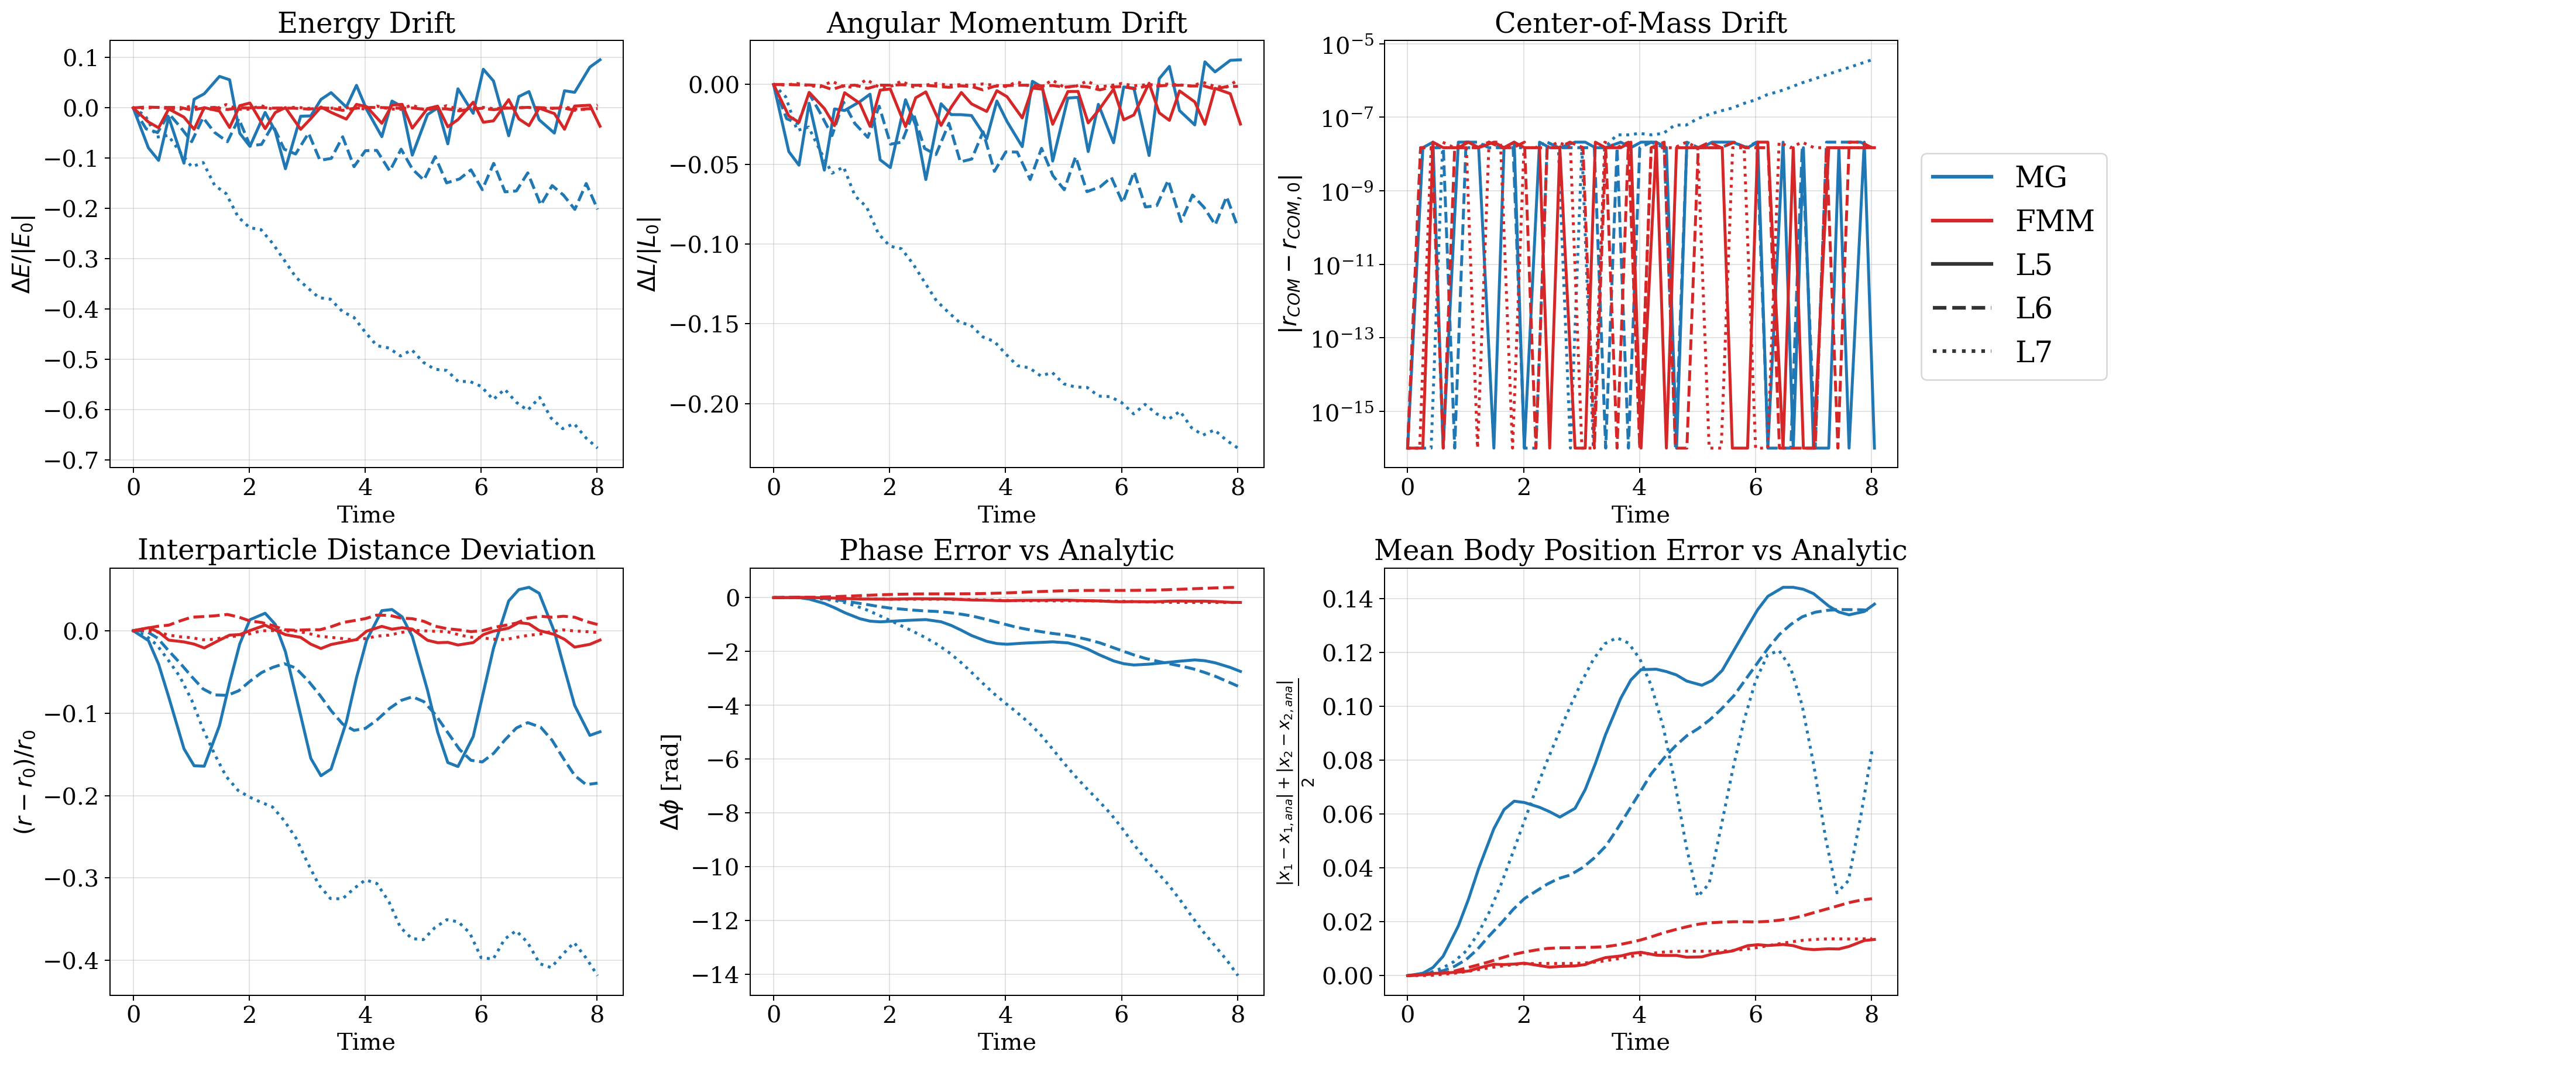

In [13]:
display(delta_df.sort_values("level").reset_index(drop=True))

display(Image(filename=str(main_png)))

/Users/jylee/Ramses-FMM/binary_test/analysis_fixed_dt_bg6/binary_fixed_dt_diagnostics.png
/Users/jylee/Ramses-FMM/binary_test/analysis_fixed_dt_bg6/binary_fixed_dt_summary.csv
/Users/jylee/Ramses-FMM/binary_test/analysis_fixed_dt_bg6/binary_fixed_dt_solver_deltas.png
/Users/jylee/Ramses-FMM/binary_test/analysis_fixed_dt_bg6/binary_fixed_dt_solver_deltas_summary.csv


,solver,level,t_end,max_abs_energy_rel_drift,max_abs_lmag_rel_drift,max_com_drift,max_abs_sep_rel_dev,max_abs_phase_err,final_phase_err,max_body_err
0,FMM,BG6_L6,8.00625,0.006879,0.003342,2.107342e-08,0.025732,0.511749,0.511749,0.038256
1,FMM,BG6_L7,8.00800,0.006659,0.003025,2.107342e-08,0.011047,0.181255,-0.181255,0.013562
2,FMM,BG6_L8,8.00280,0.019932,0.009168,2.107342e-08,0.035534,0.644984,-0.644984,0.046844
3,MG,BG6_L6,8.00625,0.031583,0.016497,2.107342e-08,0.027817,0.449325,-0.446974,0.033337
4,MG,BG6_L7,8.00800,0.984623,0.294144,1.251786e-06,0.496546,17.504463,-17.504463,0.121705
5,MG,BG6_L8,8.00280,6.845862,0.613472,5.995005e-03,0.907680,13.347978,-1.083830,0.118983


,level,t_end,max_abs_phase_diff,final_phase_diff,max_abs_sep_diff,max_abs_com_r_diff,max_abs_energy_drift_diff,max_abs_lmag_drift_diff
0,BG6_L6,8.00625,0.958724,0.958724,0.007903,2.107342e-08,0.037315,0.017398
1,BG6_L7,8.00800,17.323208,17.323208,0.074640,1.251786e-06,0.990480,0.296989
2,BG6_L8,8.00280,13.108308,0.438846,0.133119,5.994984e-03,6.839930,0.611451


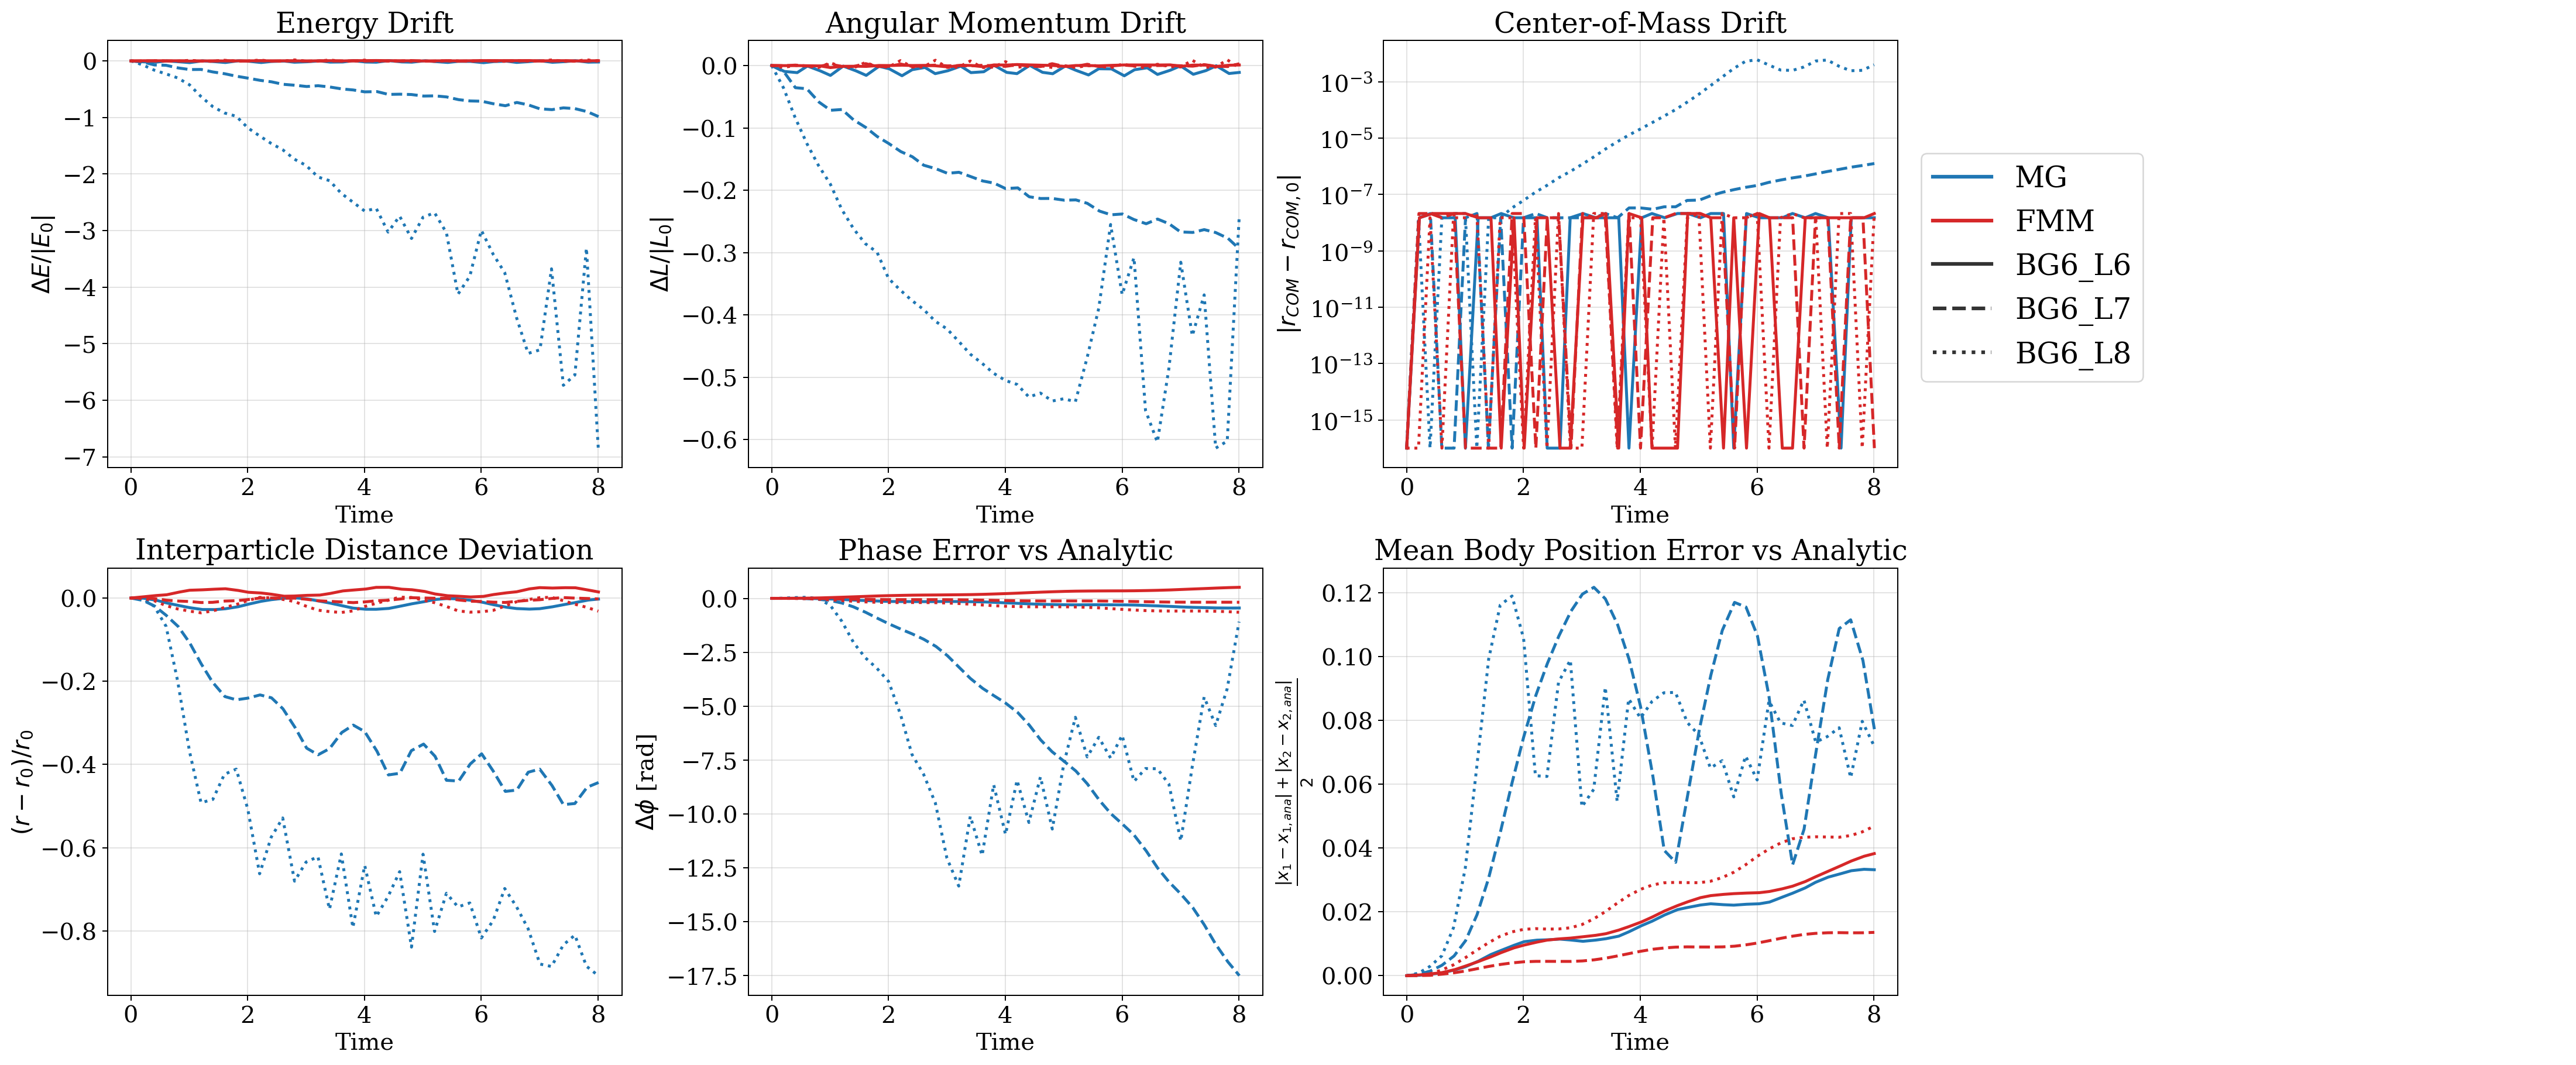

In [14]:
# New set: levelmin=6, levelmax=6/7/8 (keeps exact same plotting aesthetics)
import os
import shutil

alias_root = binary_root / ".analysis_alias_bg6"
if alias_root.exists():
    shutil.rmtree(alias_root)

for solver in ("mg", "fmm"):
    (alias_root / solver).mkdir(parents=True, exist_ok=True)

mapping = {
    "bg6_l6": "l5",
    "bg6_l7": "l6",
    "bg6_l8": "l7",
}
for solver in ("mg", "fmm"):
    for src_level, dst_level in mapping.items():
        src_dir = binary_root / solver / f"equal_mass_binary_amr_{src_level}"
        dst_dir = alias_root / solver / f"equal_mass_binary_amr_{dst_level}"
        os.symlink(src_dir, dst_dir)

output_dir_bg6 = binary_root / "analysis_fixed_dt_bg6"
summary_bg6, delta_bg6 = run_analysis(
    binary_root=alias_root,
    output_dir=output_dir_bg6,
    levels=("l5", "l6", "l7"),
    level_labels={"l5": "BG6_L6", "l6": "BG6_L7", "l7": "BG6_L8"},
)

summary_csv_bg6 = output_dir_bg6 / "binary_fixed_dt_summary.csv"
delta_csv_bg6 = output_dir_bg6 / "binary_fixed_dt_solver_deltas_summary.csv"

main_png_bg6 = output_dir_bg6 / "binary_fixed_dt_diagnostics.png"
delta_png_bg6 = output_dir_bg6 / "binary_fixed_dt_solver_deltas.png"

print(main_png_bg6)
print(summary_csv_bg6)
print(delta_png_bg6)
print(delta_csv_bg6)

display(summary_bg6.sort_values(["solver", "level"]).reset_index(drop=True))
display(delta_bg6.sort_values("level").reset_index(drop=True))

display(Image(filename=str(main_png_bg6)))

## MG Epsilon Sensitivity (BG6, L6/L7/L8)

Compare MG runs with `epsilon=1e-6` (baseline) and `epsilon=1e-8` (new run) against the same analytic reference.

- Color: epsilon value
- Line style: AMR level


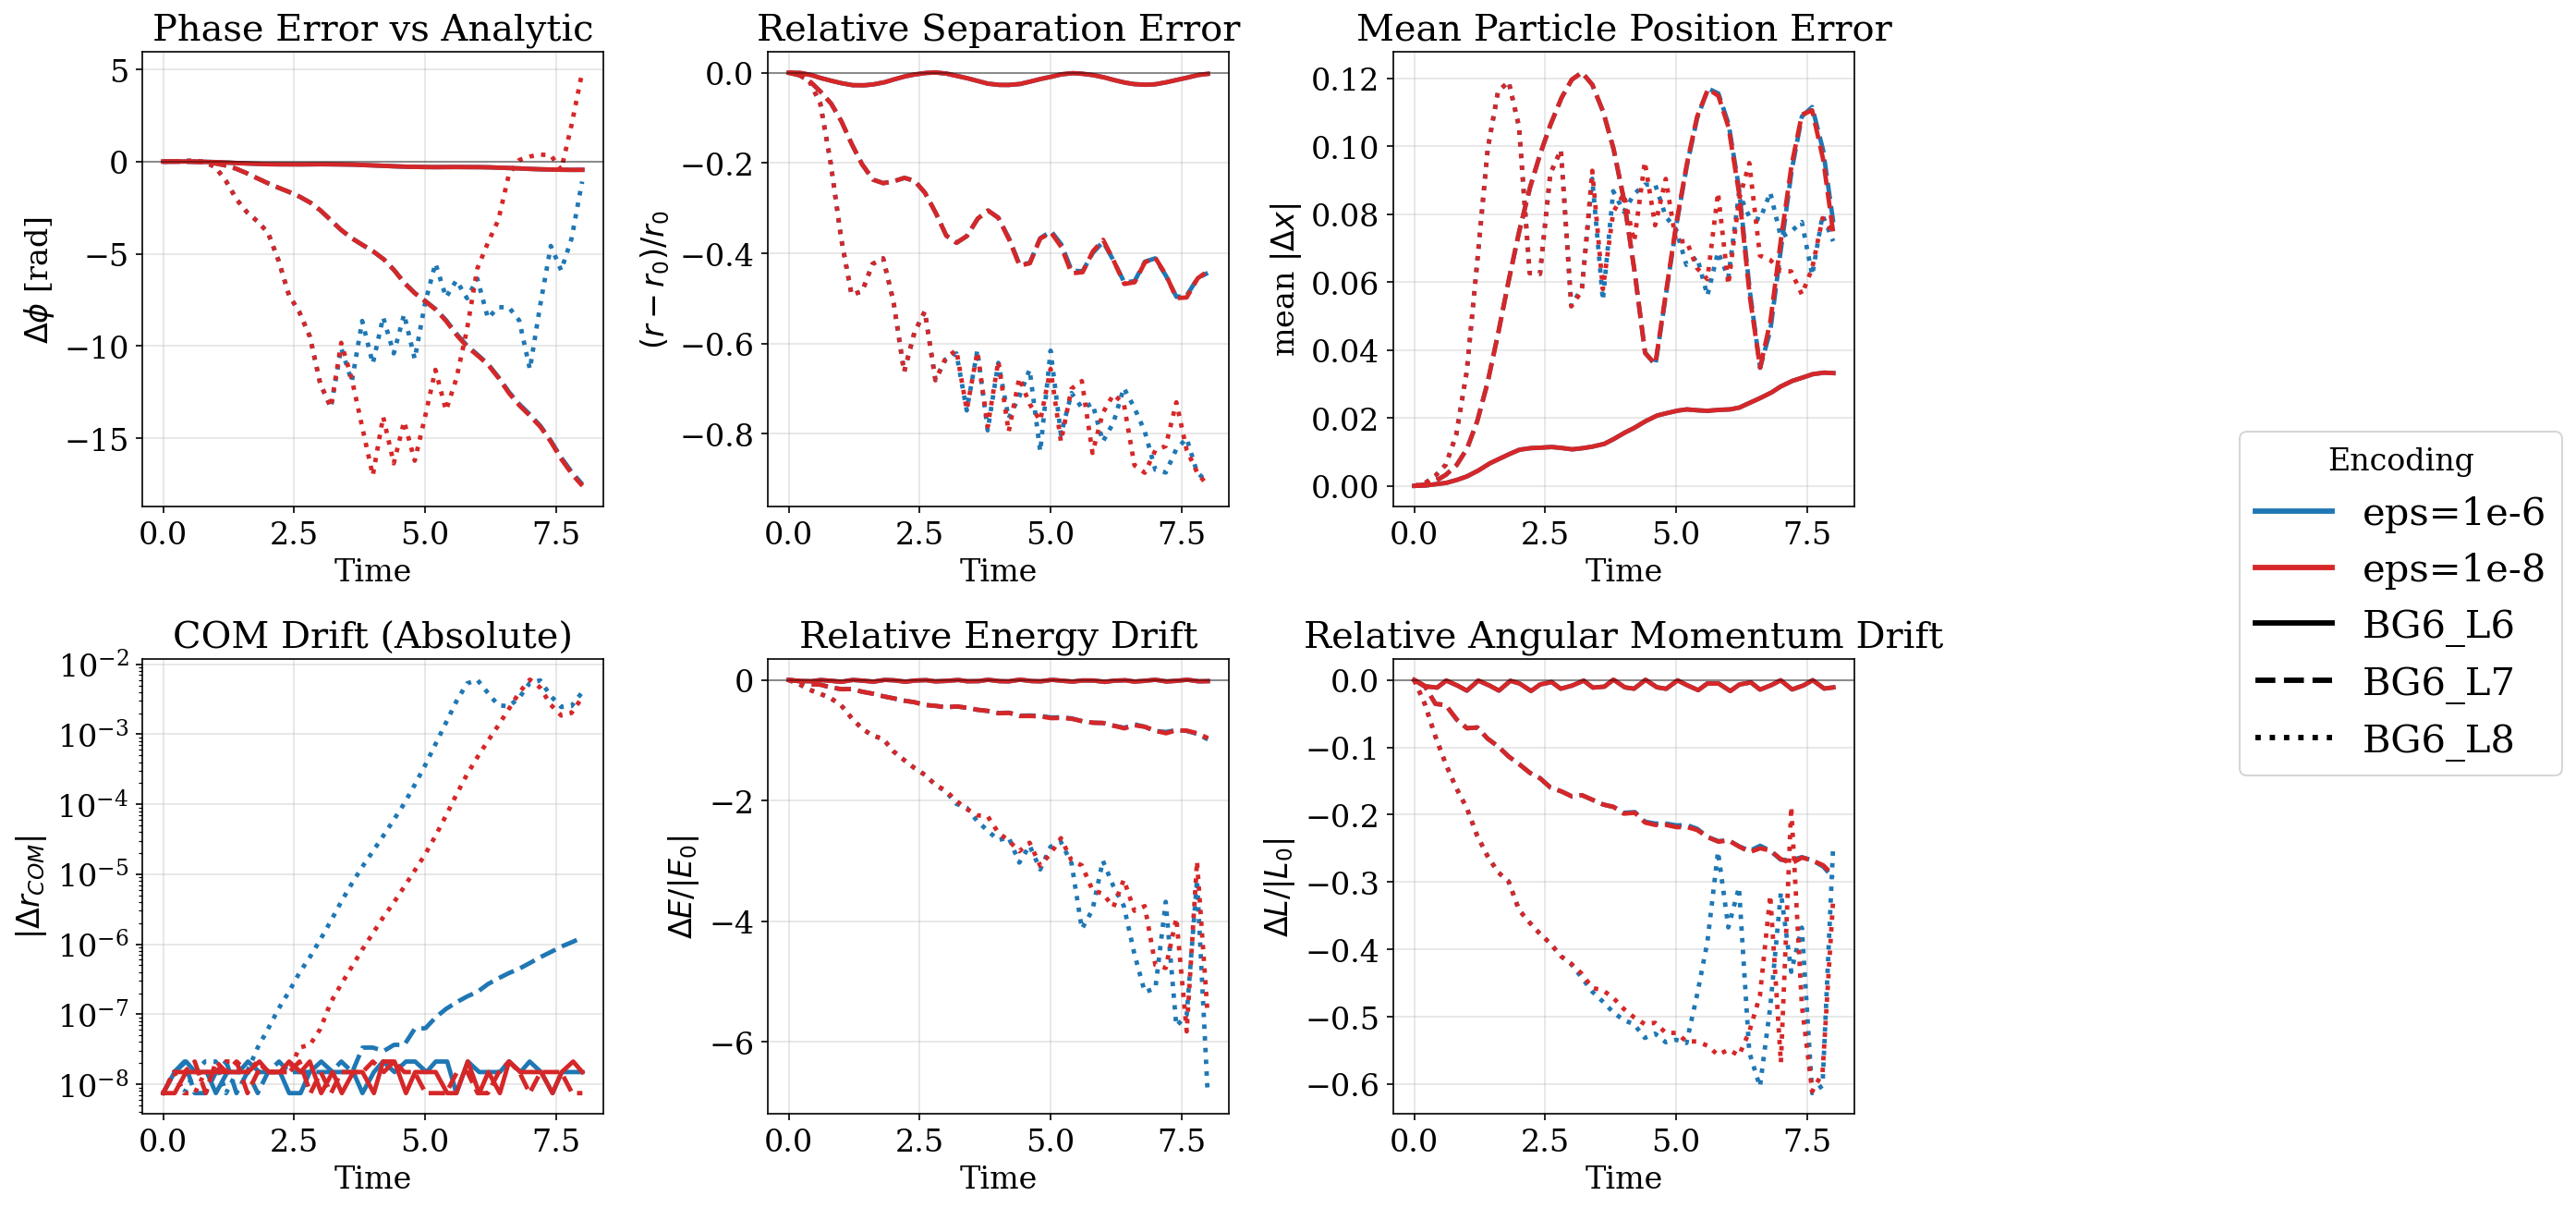

/Users/jylee/Ramses-FMM/binary_test/analysis_fixed_dt_bg6/mg_bg6_eps_compare.png
/Users/jylee/Ramses-FMM/binary_test/analysis_fixed_dt_bg6/mg_bg6_eps_compare_summary.csv


,run,level,max_abs_phase_err,max_abs_sep_rel_err,max_body_err,max_com_drift,max_abs_energy_rel_drift,max_abs_lmag_rel_drift
0,eps=1e-6,BG6_L6,0.449325,0.027817,0.033337,2.107342e-08,0.031583,0.016497
1,eps=1e-8,BG6_L6,0.449319,0.027815,0.033337,2.107342e-08,0.031584,0.016498
2,eps=1e-6,BG6_L7,17.504463,0.496546,0.121705,1.251786e-06,0.984623,0.294144
3,eps=1e-8,BG6_L7,17.586094,0.499402,0.121711,2.107342e-08,0.964068,0.290291
4,eps=1e-6,BG6_L8,13.347978,0.907680,0.118983,5.995005e-03,6.845862,0.613472
5,eps=1e-8,BG6_L8,17.022522,0.915307,0.118983,6.031245e-03,5.823648,0.610995


In [15]:
# MG-only epsilon sensitivity plotter (BG6 L6/L7/L8)

EPS_COLORS = {"eps=1e-6": "#1f77b4", "eps=1e-8": "#d62728"}
BG6_LEVELS = ("l6", "l7", "l8")
BG6_LINESTYLES = {"l6": "-", "l7": "--", "l8": ":"}
BG6_LABELS = {"l6": "BG6_L6", "l7": "BG6_L7", "l8": "BG6_L8"}


def analytic_reference(df: pd.DataFrame) -> dict[str, np.ndarray | float]:
    t = df["time"].to_numpy()
    m1 = float(df["m1"].iloc[0])
    m2 = float(df["m2"].iloc[0])
    mtot = m1 + m2

    r0 = np.array([
        df["x2"].iloc[0] - df["x1"].iloc[0],
        df["y2"].iloc[0] - df["y1"].iloc[0],
    ])
    v0 = np.array([
        df["vx2"].iloc[0] - df["vx1"].iloc[0],
        df["vy2"].iloc[0] - df["vy1"].iloc[0],
    ])

    sep0 = float(np.linalg.norm(r0))
    omega = float(np.sqrt(G * mtot / sep0**3))
    sign = float(np.sign(r0[0] * v0[1] - r0[1] * v0[0]))
    phi0 = float(np.arctan2(r0[1], r0[0]))
    phi = phi0 + sign * omega * t

    xrel = sep0 * np.cos(phi)
    yrel = sep0 * np.sin(phi)

    com_x0 = float(df["com_x"].iloc[0])
    com_y0 = float(df["com_y"].iloc[0])

    return {
        "sep0": sep0,
        "phase_ref": np.unwrap(phi),
        "x1": com_x0 - 0.5 * xrel,
        "y1": com_y0 - 0.5 * yrel,
        "x2": com_x0 + 0.5 * xrel,
        "y2": com_y0 + 0.5 * yrel,
    }


def add_diagnostics(df: pd.DataFrame, ref: dict[str, np.ndarray | float]) -> pd.DataFrame:
    out = df.copy()
    phase = np.unwrap(out["phase"].to_numpy())
    out["phase_err"] = phase - ref["phase_ref"]
    out["sep_rel_err"] = (out["sep"] - ref["sep0"]) / ref["sep0"]

    body1_err = np.sqrt((out["x1"].to_numpy() - ref["x1"])**2 + (out["y1"].to_numpy() - ref["y1"])**2)
    body2_err = np.sqrt((out["x2"].to_numpy() - ref["x2"])**2 + (out["y2"].to_numpy() - ref["y2"])**2)
    out["body_err"] = 0.5 * (body1_err + body2_err)

    com0 = out.loc[0, ["com_x", "com_y", "com_z"]].to_numpy(dtype=float)
    out["com_r"] = np.sqrt(
        (out["com_x"] - com0[0])**2
        + (out["com_y"] - com0[1])**2
        + (out["com_z"] - com0[2])**2
    )

    e0 = float(out["energy"].iloc[0])
    l0 = float(out["lmag"].iloc[0])
    out["energy_rel_drift"] = (out["energy"] - e0) / abs(e0)
    out["lmag_rel_drift"] = (out["lmag"] - l0) / abs(l0)
    return out


def positive_floor(values: pd.Series | np.ndarray) -> np.ndarray:
    arr = np.asarray(values, dtype=float)
    pos = arr[arr > 0.0]
    floor = 1e-16 if pos.size == 0 else max(float(np.min(pos)) * 0.5, 1e-16)
    return np.maximum(arr, floor)


hist_eps: dict[tuple[str, str], pd.DataFrame] = {}
for level in BG6_LEVELS:
    base_dir = binary_root / "mg" / f"equal_mass_binary_amr_bg6_{level}"
    eps8_dir = binary_root / "mg" / f"equal_mass_binary_amr_bg6_eps-8_{level}"

    base_df = load_solver_history(base_dir)
    eps8_df = load_solver_history(eps8_dir)

    ref = analytic_reference(base_df)
    hist_eps[("eps=1e-6", level)] = add_diagnostics(base_df, ref)
    hist_eps[("eps=1e-8", level)] = add_diagnostics(eps8_df, ref)


fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for eps_label, color in EPS_COLORS.items():
    for level in BG6_LEVELS:
        ls = BG6_LINESTYLES[level]
        df = hist_eps[(eps_label, level)]

        axes[0, 0].plot(df["time"], df["phase_err"], color=color, linestyle=ls, linewidth=2.3)
        axes[0, 1].plot(df["time"], df["sep_rel_err"], color=color, linestyle=ls, linewidth=2.3)
        axes[0, 2].plot(df["time"], df["body_err"], color=color, linestyle=ls, linewidth=2.3)

        axes[1, 0].plot(df["time"], positive_floor(np.abs(df["com_r"])), color=color, linestyle=ls, linewidth=2.3)
        axes[1, 1].plot(df["time"], df["energy_rel_drift"], color=color, linestyle=ls, linewidth=2.3)
        axes[1, 2].plot(df["time"], df["lmag_rel_drift"], color=color, linestyle=ls, linewidth=2.3)


titles = [
    "Phase Error vs Analytic",
    "Relative Separation Error",
    "Mean Particle Position Error",
    "COM Drift (Absolute)",
    "Relative Energy Drift",
    "Relative Angular Momentum Drift",
]

ylabels = [
    r"$\Delta \phi$ [rad]",
    r"$(r-r_0)/r_0$",
    r"mean $|\Delta x|$",
    r"$|\Delta r_{COM}|$",
    r"$\Delta E/|E_0|$",
    r"$\Delta L/|L_0|$",
]

for ax, title, ylabel in zip(axes.flat, titles, ylabels):
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel(ylabel)
    style_axis(ax)

axes[0, 0].axhline(0.0, color="black", linewidth=1.0, alpha=0.4)
axes[0, 1].axhline(0.0, color="black", linewidth=1.0, alpha=0.4)
axes[1, 1].axhline(0.0, color="black", linewidth=1.0, alpha=0.4)
axes[1, 2].axhline(0.0, color="black", linewidth=1.0, alpha=0.4)
axes[1, 0].set_yscale("log")

legend_handles = [
    Line2D([0], [0], color=EPS_COLORS[eps], lw=2.8, linestyle="-", label=eps)
    for eps in ("eps=1e-6", "eps=1e-8")
] + [
    Line2D([0], [0], color="black", lw=2.8, linestyle=BG6_LINESTYLES[level], label=BG6_LABELS[level])
    for level in BG6_LEVELS
]

fig.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=True,
)

fig.tight_layout(rect=(0, 0, 0.86, 1))

eps_plot_png = binary_root / "analysis_fixed_dt_bg6" / "mg_bg6_eps_compare.png"
eps_plot_png.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(eps_plot_png, dpi=180, bbox_inches="tight")
plt.show()

summary_rows = []
for eps_label in ("eps=1e-6", "eps=1e-8"):
    for level in BG6_LEVELS:
        df = hist_eps[(eps_label, level)]
        summary_rows.append(
            {
                "run": eps_label,
                "level": BG6_LABELS[level],
                "max_abs_phase_err": float(np.max(np.abs(df["phase_err"]))),
                "max_abs_sep_rel_err": float(np.max(np.abs(df["sep_rel_err"]))),
                "max_body_err": float(np.max(df["body_err"])),
                "max_com_drift": float(np.max(df["com_r"])),
                "max_abs_energy_rel_drift": float(np.max(np.abs(df["energy_rel_drift"]))),
                "max_abs_lmag_rel_drift": float(np.max(np.abs(df["lmag_rel_drift"]))),
            }
        )

summary_eps = pd.DataFrame(summary_rows).sort_values(["level", "run"]).reset_index(drop=True)
summary_eps_csv = binary_root / "analysis_fixed_dt_bg6" / "mg_bg6_eps_compare_summary.csv"
summary_eps.to_csv(summary_eps_csv, index=False)

print(eps_plot_png)
print(summary_eps_csv)
display(summary_eps)
